# Point Pattern

## Section 1: Data generation

### Loading packages.

In [7]:
import numpy as np
from dataclasses import dataclass
from typing import Tuple, List, Dict, Optional
import matplotlib.pyplot as plt
import gstools as gs

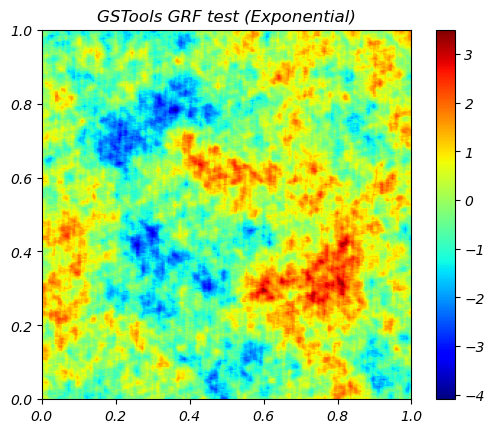

In [8]:
# generate a 2D Gaussian random field with exponential covariance

# simple example: 
# https://geostat-framework.readthedocs.io/projects/gstools/en/v1.6.1/examples/01_random_field/00_gaussian.html
# "The generated fields of gstools are ordinary Gaussian random fields." from https://geostat-framework.readthedocs.io/projects/gstools/en/stable/examples/07_transformations/index.html?utm_source=chatgpt.com

# nx, ny: Number of grid points in the x and y directions.
# L: The physical domain length, the grid spans [0, L] in both x and y
# length_scale: The correlation length of the GRF
def GRF_gen_gstools_exp(nx, ny, L, length_scale, seed):
    model = gs.Exponential(dim=2, var=1.0, len_scale=length_scale)
    SRF_generator = gs.SRF(model, seed=seed)
    x = np.linspace(0.0, L, nx)
    y = np.linspace(0.0, L, ny)
    field = SRF_generator.structured([y, x])  # Generates the GRF values on the structured grid defined by [y, x]
    field = (field - field.mean()) / field.std()
    return field

field_visual_example = GRF_gen_gstools_exp(256, 256, 1.0, 0.1, 2025)
plt.imshow(field_visual_example, origin="lower", extent=[0, 1, 0, 1], cmap="jet")
plt.colorbar()
plt.title("GSTools GRF test (Exponential)")
plt.show()

In [20]:
@dataclass # Dataclasses auto-generate __init__... Do not remove e.g. "int", "float" here besides the parameters.
class simulation_params:
    p: int                    = 4                         # number of types of points, it must match the lengths of phi, alpha, sigma, gamma0, gamma1.
    L: float                  = 1.0                       # window size (domain [0,L] x [0,L])
    nx: int                   = 256                       # grid resolution (x), pixel sizes are dx=L/nx, dy=L/ny. 
    ny: int                   = 256                       # grid resolution (y), Larger values = finer field & intensity maps.
    xi: float                 = 0.1                       # Length-scale for the shared Gaussian field Y.
    phi: Tuple[float, ...]    = (0.05, 0.05, 0.05, 0.05)  # Per-type length-scales for type-specific fields U_i.
    alpha: Tuple[float, ...]  = (0.5, -0.4, 0.6, -0.3)    # Coefficients for the shared field Y inside each type’s intensity.
    sigma: Tuple[float, ...]  = (np.sqrt(0.5), np.sqrt(0.5), np.sqrt(0.5), np.sqrt(0.5)) # Std devs of the type-specific field U_i, sigma_i^2 = 0.5
    gamma0: Tuple[float, ...] = (5.17, 5.44, 5.88, 6.13)  # Intercepts for log-intensity fixed component of each type
    gamma1: Tuple[float, ...] = (0.0, 0.3, -0.6, 0.6)     # Slopes for the covariate field z(u) in each type’s fixed component.
    background_coeff: float   = 0.5                       # lambda0(u) = exp(background_coeff*V(u)-*background_coeff^2/2), Sets a background lognormal field
    V_scale: float            = 0.05                      # scale parameter for V(u) field be set as 0.05
    z_scale: float            = 0.05                      # scale parameter for z(u) field be set as 0.05, chosen as an independent copy of V(u)
    seed: int                 = 123                       # the seed number
    seed_z: int               = 2025                      # required a different seed for z (a independent "copy" of V)

In [21]:
def simulate_point_pattern(params):
    # reading pre-defined parameters: 
    p = params.p
    L = params.L
    nx = params.nx
    ny = params.ny
    dx = L/nx # pixel length in x
    dy = L/ny # in y
    pixel_area = dx*dy
    rng = np.random.default_rng(params.seed)
    alpha = np.asarray(params.alpha)
    sigma = np.asarray(params.sigma)
    gamma0 = np.asarray(params.gamma0)
    gamma1 = np.asarray(params.gamma1)
    V_field_scale_para = params.V_scale
    z_field_scale_para = params.z_scale
    Y_filed_scale_para_xi = params.xi
    lambda0_coeff = params.background_coeff

    # Compute 4 Gaussian random fields: V(u), z(u), shared Y(u), types U_i (u)
    V = GRF_gen_gstools_exp(nx, ny, L, length_scale = V_field_scale_para, seed = params.seed)
    z = GRF_gen_gstools_exp(nx, ny, L, length_scale = z_field_scale_para, seed = params.seed_z)
    Y = GRF_gen_gstools_exp(nx, ny, L, length_scale = Y_filed_scale_para_xi, seed = params.seed)
    U_list = []
    for i in range(p):
        phi_i = params.phi[i]
        U_i = GRF_gen_gstools_exp(nx, ny, L, length_scale = phi_i, seed = params.seed)
        U_list.append(U_i)

    # Compute Baseline intensity function lambda0(u) and types intensities Lambda(u)_i:
    lambda0 = np.exp(lambda0_coeff*V - (lambda0_coeff**2)/2)
    Lambda_list = []
    for i in range(p):
        Lambda_i = lambda0*np.exp(gamma0[i] + gamma1[i]*z)*np.exp(alpha[i]*Y + sigma[i]*U_list[i] - (alpha[i]**2)/2 - (sigma[i]**2)/2)
        Lambda_list.append(Lambda_i)

    # Poisson
    points_by_type = []
    point_labels = []
    for i in range(p):
        # Lambda_list[i] is a 2D shape (ny, nx) intensity values for all pixels for type i
        # intensity × area = expected count, multiply the intensity at each pixel by the area of that pixel
        # For each pixel, draw the random number of points from a Poisson distribution with that expected count.
        # a Poisson point process conditional on the intensity field. For each pixel (x,y), draw a random number of points with mean_counts[x,y]
        counts = rng.poisson(Lambda_list[i]*pixel_area)  # 2D counts. use Expected number of events occurring
        n_type_i = int(counts.sum()) # total number of points of type i across the whole window.
        ys, xs = np.nonzero(counts) # returns the coordinates (x, y) of all occupied pixels that have at least 1 point.
        n_points_pixel = counts[ys, xs] # For each occupied pixel (ys[k], xs[k]), n_points_pixel[k] tells our how many points are in that pixel.
        
        if n_type_i > 0:
            ys_expand = np.repeat(ys, n_points_pixel)
            xs_expand = np.repeat(xs, n_points_pixel)
            x_coords = (xs_expand + rng.uniform(0.0, 1.0, size=n_type_i))*dx # to physical coordinates from pixel coordinates
            y_coords = (ys_expand + rng.uniform(0.0, 1.0, size=n_type_i))*dy
            points = np.column_stack([x_coords, y_coords])
        else:
            points = np.empty((0, 2)) # 2 columns 0 row, empty.
            
        points_by_type.append(points)
        point_labels.extend([i + 1]*points.shape[0]) # index 0 to lebel 1 and so on.

    labels = np.asarray(point_labels, dtype=int) # convert labels data type

    return {
        'points_by_type': points_by_type,
        'labels': labels,
        'Lambda_list': Lambda_list,
        'lambda_base': lambda0,
        'log_lambda_base': np.log(lambda0),
        'grid_data': {'L': L, 'nx': nx, 'ny': ny, 'dx': dx, 'dy': dy},
        'fields': {'V': V, 'z': z, 'Y': Y, 'U_list': U_list},
        'params': params,
    }

In [35]:
# possion function test
#print(np.random.poisson(2,100))
print(np.random.poisson(2,100).mean())

rng1 = np.random.default_rng()
lam = np.array([1,2,3,4]).reshape(2,2)
samples = rng1.poisson(lam, size=(100,2,2))
print(samples.shape)   # (100, 2, 2)
print(samples.mean(axis=0))

[1 6 2 0 2 2 0 3 1 0 2 5 1 3 3 2 4 1 3 0 0 3 0 1 2 2 0 6 3 4 3 2 2 1 1 3 5
 4 3 3 2 0 2 3 2 0 2 4 0 0 5 3 1 4 2 2 1 3 3 2 2 2 0 7 1 0 1 3 2 0 0 0 0 1
 1 1 2 2 3 3 0 1 3 4 1 1 1 3 3 2 2 1 5 2 1 2 0 3 7 0]
1.88
(100, 2, 2)
[[0.95 1.96]
 [2.9  3.9 ]]


In [22]:
def true_cross_pcf(r, alpha, sigma2, xi, phi, i, j):
    r = np.asarray(r)
    part1 = np.exp(alpha[i]*alpha[j]*np.exp(-r/xi))
    part2 = np.exp(sigma2[i]*np.exp(-r/phi[i]))
    if i == j:
        return part1*part2
    else:
        return part1

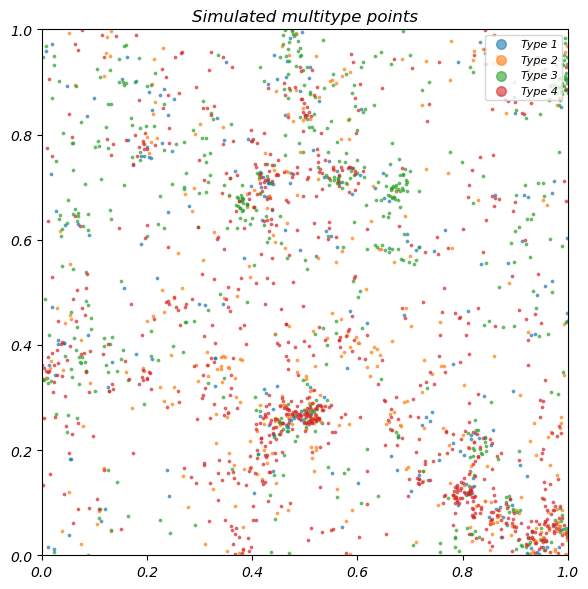

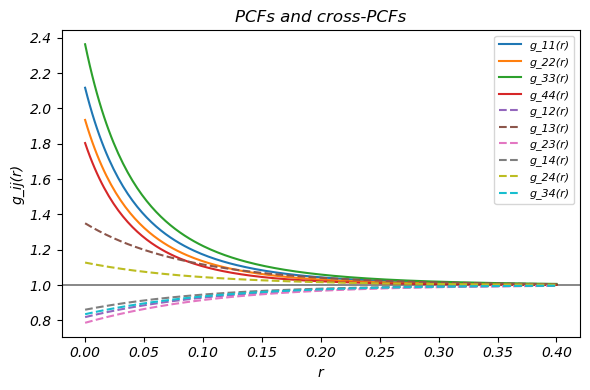

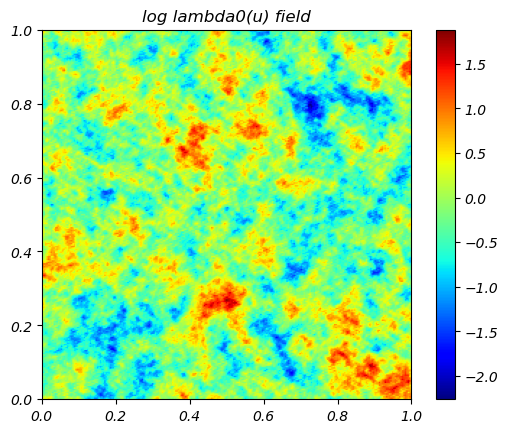

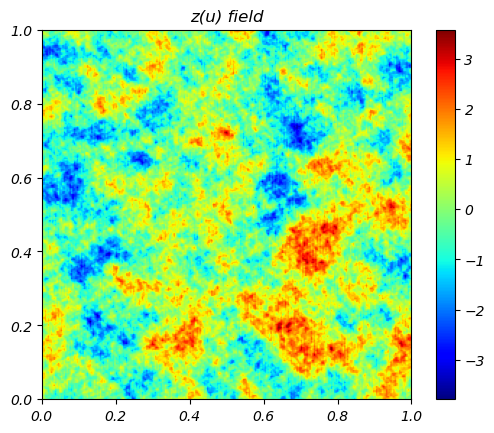

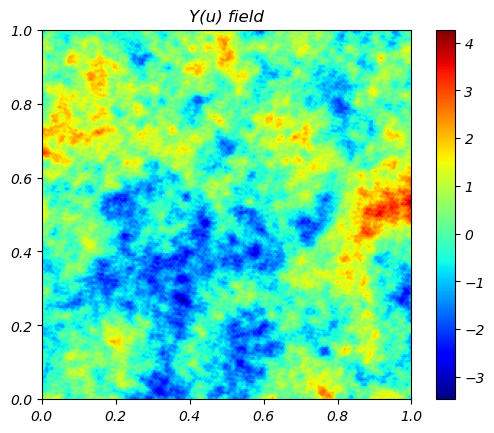

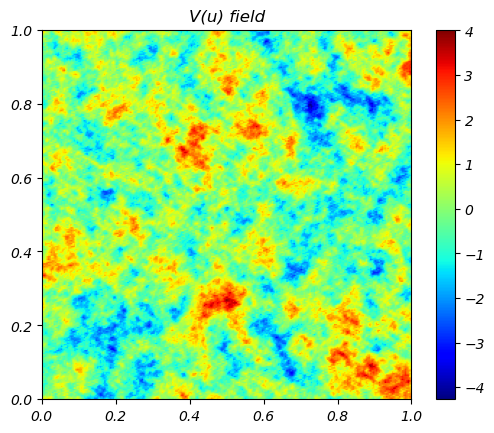

In [23]:
# main
params = simulation_params()
pp_simulation = simulate_point_pattern(params)

plt.figure(figsize=(6, 6))
colors = ["C0", "C1", "C2", "C3"] 
for i, points in enumerate(pp_simulation['points_by_type']):
    if points.size:
        plt.scatter(points[:, 0], points[:, 1], s=3, alpha=0.6, label=f"Type {i+1}", color=colors[i % len(colors)])
plt.xlim(0, params.L)
plt.ylim(0, params.L)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Simulated multitype points")
plt.legend(markerscale=4, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

r = np.linspace(0, 0.4, 200)
alpha = np.asarray(params.alpha)
sigma2 = np.asarray(params.sigma)**2
phi = np.asarray(params.phi)
plt.figure(figsize=(6, 4))
for i in range(params.p):
    gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, i, i)
    plt.plot(r, gij, label=f"g_{i+1}{i+1}(r)")
    plt.axhline(y=1.0, color='black', linewidth=0.2)
if params.p >= 2:
    gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, 0, 1)
    plt.plot(r, gij, linestyle='--', label="g_12(r)")
if params.p >= 3:
    gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, 0, 2)
    plt.plot(r, gij, linestyle='--', label="g_13(r)")
    gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, 1, 2)
    plt.plot(r, gij, linestyle='--', label="g_23(r)")
if params.p >= 4:
    gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, 0, 3)
    plt.plot(r, gij, linestyle='--', label="g_14(r)")
    gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, 1, 3)
    plt.plot(r, gij, linestyle='--', label="g_24(r)")
    gij = true_cross_pcf(r, alpha, sigma2, params.xi, phi, 2, 3)
    plt.plot(r, gij, linestyle='--', label="g_34(r)")
plt.xlabel("r")
plt.ylabel("g_ij(r)")
plt.title("PCFs and cross-PCFs")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.imshow(pp_simulation['log_lambda_base'], origin="lower", extent=[0,1,0,1], cmap="jet")
plt.title("log lambda0(u) field")
plt.colorbar()
plt.show()

plt.imshow(pp_simulation['fields']['z'], origin="lower", extent=[0,1,0,1], cmap="jet")
plt.title("z(u) field")
plt.colorbar()
plt.show()

plt.imshow(pp_simulation['fields']['Y'], origin="lower", extent=[0,1,0,1], cmap="jet")
plt.title("Y(u) field")
plt.colorbar()
plt.show()

plt.imshow(pp_simulation['fields']['V'], origin="lower", extent=[0,1,0,1], cmap="jet")
plt.title("V(u) field")
plt.colorbar()
plt.show()

In [ ]:
import rpy2.robjects as ro
from rpy2.robjects.packages import importr

stats = importr("stats")

# Call R's rnorm()
x = stats.rnorm(10)
print(x)
